# 04 · Periodic–aperiodic parameterization 
Fit each linear Welch PSD with the same knee-mode settings used in the original
FOOOF notebook. Export the aperiodic fit, flattened spectrum, parameters and fit QC.

**Run 03 first.** This example does not interpolate frequency bins. It is a fresh
illustration of parameterization, not a reproduction of archived interpolated spectra.


## 1. Imports, input files and model settings 


In [ ]:
from pathlib import Path
import os, csv
import numpy as np
from scipy.io import loadmat, savemat
import matplotlib.pyplot as plt

# Open Jupyter in this code folder, or set the environment path explicitly.
code_dir = Path(os.environ.get('GATE_OFFLINE_CODE_DIR', '.')).resolve()
assert (code_dir/'example_inputs/lfp_examples.csv').is_file(), 'Open this notebook from its own code folder.'
output_root = Path(os.environ.get('GATE_EXAMPLE_OUTPUT_DIR', code_dir/'_example_outputs'))
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

from fooof import FOOOF
input_dir = output_root/'03_welch'
out_dir = output_root/'04_parameterization'
out_dir.mkdir(parents=True, exist_ok=True)
with (input_dir/'processed_manifest.csv').open(encoding='utf-8') as handle:
    examples = list(csv.DictReader(handle))
fit_range = [2, 90]
peak_width_limits = [2, 15]        # Hz
maximum_peaks = 6
minimum_peak_height = 0.20        # Native log10 fit scale, equivalent to 2 dB
aperiodic_mode = 'knee'


## 2. Fit spectra
Pass linear power to FOOOF; it logs the data internally. In knee mode the parameter
order is **offset, knee, exponent**. Inspect fit quality and residual structure;
an R² alone does not certify that peaks are neural or artifacts are absent.


In [2]:
fits = []; quality_rows = []
for row in examples:
    saved = loadmat(input_dir/(row['ExampleID']+'_psd.mat'), squeeze_me=True)
    frequency = np.asarray(saved['freq'], dtype=float).reshape(-1)
    psd = np.asarray(saved['psd_linear'], dtype=float).reshape(-1)
    assert np.all(np.diff(frequency) > 0) and np.all(psd > 0)
    model = FOOOF(peak_width_limits=peak_width_limits, max_n_peaks=maximum_peaks,
                  min_peak_height=minimum_peak_height, aperiodic_mode=aperiodic_mode,
                  verbose=False)
    model.fit(frequency, psd, fit_range)
    offset, knee, exponent = model.aperiodic_params_
    background_argument = knee + frequency**exponent
    assert np.all(background_argument > 0), 'Invalid fitted aperiodic background.'
    aperiodic_log10 = offset - np.log10(background_argument)
    # Verify against the fitted background for the pinned FOOOF 1.1.0 version.
    np.testing.assert_allclose(aperiodic_log10, model._ap_fit, rtol=1e-10, atol=1e-10)
    flattened_db = 10*(np.log10(psd) - aperiodic_log10)
    assert np.isfinite(flattened_db).all()
    result = dict(freq=frequency, psd_linear=psd, aperiodic_log10=aperiodic_log10,
                  flat_db=flattened_db, offset_log10=offset, offset_db=10*offset,
                  knee=knee, exponent=exponent, r_squared=model.r_squared_,
                  fit_error=model.error_, full_model_log10=model.fooofed_spectrum_,
                  peak_params=model.peak_params_)
    savemat(out_dir/(row['ExampleID']+'_fit.mat'), result)
    quality_rows.append(dict(ExampleID=row['ExampleID'], R_squared=model.r_squared_,
                             FitError_log10=model.error_, NPeaks=model.n_peaks_,
                             Offset_dB=10*offset, Knee=knee, Exponent=exponent))
    fits.append(dict(row=row, **result))
with (out_dir/'fit_quality.csv').open('w', newline='', encoding='utf-8') as handle:
    writer=csv.DictWriter(handle, fieldnames=quality_rows[0].keys())
    writer.writeheader(); writer.writerows(quality_rows)
with (out_dir/'processed_manifest.csv').open('w', newline='', encoding='utf-8') as handle:
    writer=csv.DictWriter(handle, fieldnames=examples[0].keys())
    writer.writeheader(); writer.writerows(examples)
for row in quality_rows:
    print(row['ExampleID'], f"R2={row['R_squared']:.3f}, error={row['FitError_log10']:.3f}")


Rat07_130Hz_OL_Pre_seg010 R2=0.950, error=0.050
Rat07_130Hz_OL_Pre_seg006 R2=0.928, error=0.060
Rat07_130Hz_OL_Stim_seg009 R2=0.973, error=0.053
Rat07_130Hz_OL_Stim_seg010 R2=0.964, error=0.051
Rat07_130Hz_OL_Post_seg011 R2=0.988, error=0.053
Rat07_130Hz_OL_Post_seg005 R2=0.989, error=0.048
Rat08_130Hz_OL_Pre_seg006 R2=0.989, error=0.048
Rat08_130Hz_OL_Pre_seg010 R2=0.988, error=0.049
Rat08_130Hz_OL_Stim_seg011 R2=0.987, error=0.053
Rat08_130Hz_OL_Stim_seg007 R2=0.990, error=0.047
Rat08_130Hz_OL_Post_seg002 R2=0.986, error=0.049
Rat08_130Hz_OL_Post_seg001 R2=0.983, error=0.054


## 3. Understand the reported units
Flattened power is ten times the difference between log10 PSD and the fitted
log10 background, so it is **dB relative to the aperiodic background**. Offset is
also multiplied by ten for reporting. Exponent and knee retain their native units.
Flattened values may be negative. They are not linear PSD or Gaussian peak heights.


## 4. Inspect the full fit and flattened spectrum


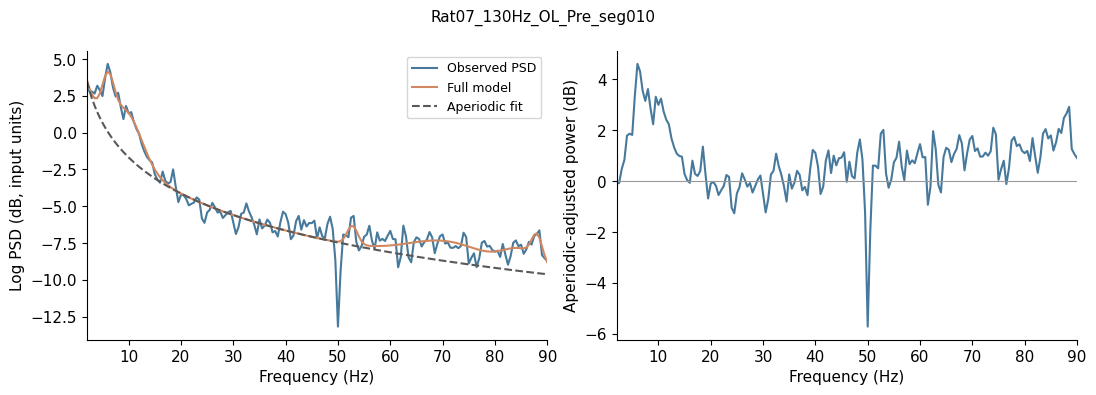

In [3]:
example = fits[0]
f = example['freq']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(f, 10*np.log10(example['psd_linear']), color='#46799c', label='Observed PSD')
axes[0].plot(f, 10*example['full_model_log10'], color='#d18860', label='Full model')
axes[0].plot(f, 10*example['aperiodic_log10'], '--', color='0.35', label='Aperiodic fit')
axes[0].set_ylabel('Log PSD (dB, input units)'); axes[0].legend(fontsize=9)
axes[1].plot(f, example['flat_db'], color='#46799c')
axes[1].axhline(0, color='0.6', lw=0.8)
axes[1].set_ylabel('Aperiodic-adjusted power (dB)')
for ax in axes: ax.set(xlabel='Frequency (Hz)', xlim=fit_range)
fig.suptitle(example['row']['ExampleID'], fontsize=11)
fig.tight_layout(); fig.savefig(out_dir/'parameterization_QC.png', dpi=180)
plt.show()


## 5. Next step and interpretation
Run **step05_band_power.mlx**, then **step06_rat_level_summary.mlx** in MATLAB.
Each animal receives equal weight after averaging its segments within phase.
No fit is silently excluded for having inconvenient power values or effect directions.
Residual line/stimulation artifacts require separate QC and are not solved by FOOOF.
